In [49]:
import os
import csv
from pathlib import Path
import pandas as pd
import numpy as np

In [50]:
os.chdir("/content/drive/MyDrive/SEC")

In [51]:
# Convert text files to csv
input_dir = Path('/content/drive/MyDrive/SEC')
output_dir = Path('/content/drive/MyDrive/SEC')


output_dir.mkdir(parents=True, exist_ok=True)

txt_files = sorted(input_dir.glob('*.txt'))
print(f"Found {len(txt_files)} file(s) to convert\n")

for i, input_path in enumerate(txt_files, 1):
    output_path = output_dir / (input_path.stem + '.csv')
    print(f"[{i}/{len(txt_files)}] {input_path.name} -> {output_path.name}")

    if output_path.exists():
        print(f"   Skipping (already exists)\n")
        continue

    try:
        row_count = 0
        with open(input_path, 'r', encoding='utf-8', newline='') as f_in:
            reader = csv.reader(f_in, delimiter='\t', quoting=csv.QUOTE_NONE)
            with open(output_path, 'w', encoding='utf-8', newline='') as f_out:
                writer = csv.writer(f_out, quoting=csv.QUOTE_MINIMAL)
                for row in reader:
                    writer.writerow(row)
                    row_count += 1
        print(f"   ✓ {row_count:,} rows\n")
    except Exception as e:
        print(f"   ✗ Failed: {e}\n")

print("Done.")

Found 7 file(s) to convert

[1/7] cik_ticker_latest.txt -> cik_ticker_latest.csv
   Skipping (already exists)

[2/7] num_2023.txt -> num_2023.csv
   Skipping (already exists)

[3/7] num_2024.txt -> num_2024.csv
   Skipping (already exists)

[4/7] num_2025.txt -> num_2025.csv
   Skipping (already exists)

[5/7] sub_2023.txt -> sub_2023.csv
   Skipping (already exists)

[6/7] sub_2024.txt -> sub_2024.csv
   Skipping (already exists)

[7/7] sub_2025.txt -> sub_2025.csv
   Skipping (already exists)

Done.


In [52]:
df = pd.read_csv('cik_ticker_latest.txt')

# Save it as a CSV
df.to_csv('cik_ticker_latest.csv', index=False)

In [53]:
annual_revenue = pd.read_csv('annual_revenue.csv')

In [54]:
annual_revenue.head(10)

,company,cik,fiscal_year,revenue_value,adsh,tag,form,qtrs,segments,coreg,uom,ddate,filed,source_quarter_num,source_quarter_sub
0,Airbnb,1559720,2022,8.399000e+09,0001559720-25-000010,RevenueFromContractWithCustomerExcludingAssess...,10-K,4,NaN,NaN,USD,20221231,20250213,2025q1,2025q1
1,Airbnb,1559720,2023,9.917000e+09,0001559720-25-000010,RevenueFromContractWithCustomerExcludingAssess...,10-K,4,NaN,NaN,USD,20231231,20250213,2025q1,2025q1
2,Airbnb,1559720,2024,1.110200e+10,0001559720-25-000010,RevenueFromContractWithCustomerExcludingAssess...,10-K,4,NaN,NaN,USD,20241231,20250213,2025q1,2025q1
3,Amazon,1018724,2022,5.139830e+11,0001018724-25-000004,RevenueFromContractWithCustomerExcludingAssess...,10-K,4,NaN,NaN,USD,20221231,20250207,2025q1,2025q1
4,Amazon,1018724,2023,5.747850e+11,0001018724-25-000004,RevenueFromContractWithCustomerExcludingAssess...,10-K,4,NaN,NaN,USD,20231231,20250207,2025q1,2025q1
5,Amazon,1018724,2024,6.379590e+11,0001018724-25-000004,RevenueFromContractWithCustomerExcludingAssess...,10-K,4,NaN,NaN,USD,20241231,20250207,2025q1,2025q1
6,Apple,320193,2022,3.943280e+11,0000320193-24-000123,RevenueFromContractWithCustomerExcludingAssess...,10-K,4,NaN,NaN,USD,20220930,20241101,2024q4,2024q4
7,Apple,320193,2023,3.832850e+11,0000320193-25-000079,RevenueFromContractWithCustomerExcludingAssess...,10-K,4,NaN,NaN,USD,20230930,20251031,2025q4,2025q4
8,Apple,320193,2024,3.910350e+11,0000320193-25-000079,RevenueFromContractWithCustomerExcludingAssess...,10-K,4,NaN,NaN,USD,20240930,20251031,2025q4,2025q4
9,Google,1652044,2022,2.828360e+11,0001652044-25-000014,RevenueFromContractWithCustomerExcludingAssess...,10-K,4,NaN,NaN,USD,20221231,20250205,2025q1,2025q1


# Data Cleaning

## 1. Stock data

In [55]:
stock_prices = pd.read_csv("Stocks.csv")
stock_prices

,date,ticker,open,high,low,close,adj_close,volume
0,2023-01-03,AAPL,130.279999,130.899994,124.169998,125.070000,123.096016,112117500.0
1,2023-01-04,AAPL,126.889999,128.660004,125.080002,126.360001,124.365669,89113600.0
2,2023-01-05,AAPL,127.129997,127.769997,124.760002,125.019997,123.046806,80962700.0
3,2023-01-06,AAPL,126.010002,130.289993,124.889999,129.619995,127.574211,87754700.0
4,2023-01-09,AAPL,130.470001,133.410004,129.889999,130.149994,128.095856,70790800.0
...,...,...,...,...,...,...,...,...
12977,2026-05-04,CRM,203.089436,200.949890,199.924061,208.807463,203.140780,4150102.0
12978,2025-07-14,AAPL,245.820593,245.834648,247.628572,250.355898,246.030667,43066579.0
12979,2026-02-24,ABNB,126.740978,125.520657,123.128982,129.149601,123.714131,5343352.0
12980,2026-12-08,GOOGL,164.226348,161.191651,161.991729,158.092562,158.450870,25613882.0


In [56]:
NUMERIC_COLS = ["open", "high", "low", "close", "adj_close", "volume"]
KEY_COLS = ["date", "ticker"]

In [57]:
#standardize column names
stock_prices.columns = stock_prices.columns.str.strip().str.lower().str.replace(r"\s+", "_", regex=True)

In [58]:
#standardize ticker feature
stock_prices["ticker"] = (
    stock_prices["ticker"].astype("string").str.strip().str.upper().replace({"": pd.NA})
)

In [59]:
#convert date feature to dattime format
stock_prices["date"] = pd.to_datetime(stock_prices["date"], errors="coerce")

In [60]:
for col in NUMERIC_COLS:
    if col in stock_prices.columns:
        stock_prices[col] = pd.to_numeric(stock_prices[col], errors="coerce")

In [61]:
#replace negative values to Nan
neg_volume = (stock_prices["volume"] < 0).sum()
print(f"  [impossible volume] {neg_volume} negative volume(s) -> NaN")
stock_prices.loc[stock_prices["volume"] < 0, "volume"] = np.nan

  [impossible volume] 906 negative volume(s) -> NaN


In [62]:
#drop rows with missing key features
before = len(stock_prices)
stock_prices = stock_prices.dropna(subset=KEY_COLS).copy()
print(f"  [drop missing key] rows {before:>6} -> {len(stock_prices):>6}  (removed {before - len(stock_prices)})")

  [drop missing key] rows  12982 ->  12798  (removed 184)


In [63]:
#remove duplicates
before = len(stock_prices)
stock_prices = stock_prices.drop_duplicates().copy()
print(f"  [drop full dupes ] rows {before:>6} -> {len(stock_prices):>6}  (removed {before - len(stock_prices)})")

  [drop full dupes ] rows  12798 ->  11662  (removed 1136)


In [64]:
#Remove duplicate (date, ticker) pairs, and keep the one with the least Nan, or keep the first record in case of a tiebreaker.
before = len(stock_prices)
stock_prices["nan_count"] = stock_prices[NUMERIC_COLS].isna().sum(axis=1)
stock_prices= (
    stock_prices.sort_values(["nan_count", "volume"], ascending=[True, False])
    .drop_duplicates(subset=KEY_COLS, keep="first")
    .drop(columns="nan_count")
)
print(f"  [dedupe by key   ] rows {before:>6} -> {len(stock_prices):>6}  (removed {before - len(stock_prices)})")


  [dedupe by key   ] rows  11662 ->  10051  (removed 1611)


In [65]:
print(f"Final rows:    {len(stock_prices)}")
stock_prices

Final rows:    10051


,date,ticker,open,high,low,close,adj_close,volume
3486,2023-12-15,UBER,62.160000,63.529999,61.410000,61.860001,61.860001,364261200.0
8478,2022-07-10,UBER,62.160000,63.529999,61.410000,64.800599,64.800599,364261200.0
431,2024-09-20,AAPL,229.970001,233.089996,227.619995,228.199997,226.710754,318679900.0
9245,2022-10-06,AAPL,223.067595,233.089996,227.619995,228.199997,226.710754,318679900.0
2722,2023-01-27,TSLA,162.429993,180.679993,161.169998,177.899994,177.899994,306590600.0
...,...,...,...,...,...,...,...,...
6839,2025-12-12,AAPL,NaN,194.990005,192.520004,194.029999,192.540878,NaN
6874,2025-08-03,LYFT,12.350000,12.470000,11.920000,12.380000,NaN,NaN
6883,2025-12-20,ABNB,144.630005,145.690002,NaN,139.449997,139.449997,NaN
6884,2025-05-23,MSFT,417.899994,NaN,417.269989,423.079987,417.435974,NaN


In [66]:
stock_prices.to_csv("Stocks_cleaned.csv", index=False)

### 2. News data

In [67]:
company_news = pd.read_csv("News.csv")
company_news

,Time/Date,Tickers,Headlines
0,30-May-2024 07:55,tsla,Analysts weigh in on TSLA ahead of macro data
1,2024/12/23 15:58:55,$ CRM $CRM,Sector rotation lifts CRM in late trade
2,2024-10-05T12:51:40,$ABNB,ABNB active in premarket as volume spikes
3,01-May-2020 10:00,UBER,UBER moves on headline cross-asset flows
4,12/04/2024 09:36 AM,$AMZN,AMZN active in premarket as volume spikes
...,...,...,...
27995,2023-11-06T15:39:30,$TSLA,"""Sector rotation lifts TSLA in late trade"""
27996,01/16/2025 04:36 PM,$ TSLA $TSLA,Analysts weigh in on TSLA ahead of macro data
27997,2024-09-08 14:27:00,$ZZTOP,Traders debate valuation for ABNB into quarter...
27998,27-May-2024 11:57,$ AMZN $AMZN,Sector rotation lifts AMZN in late trade


In [68]:
top10_tickers = {
    "AAPL", "ABNB", "AMZN", "CRM", "GOOGL",
    "LYFT", "META", "MSFT", "TSLA", "UBER",
}

In [69]:
date_formats = [
    "%Y-%m-%d %H:%M:%S",   # 2024-03-22 09:07:23
    "%Y-%m-%dT%H:%M:%S",   # 2024-10-05T12:51:40
    "%Y/%m/%d %H:%M:%S",   # 2024/12/23 15:58:55
    "%d-%b-%Y %H:%M",      # 30-May-2024 07:55
    "%b %d, %Y %H:%M:%S",  # Feb 12, 2025 12:24:46
    "%m/%d/%Y %I:%M %p",   # 12/04/2024 09:36 AM (US convention)
]

In [70]:
#standardize columns
company_news.columns = (
    company_news.columns.str.strip()
    .str.lower()
    .str.replace(r"[/\s]+", "_", regex=True)  # "Time/Date" -> "time_date"
)
company_news = company_news.rename(columns={"time_date": "datetime", "headlines": "headline",
                        "tickers": "ticker"})

In [71]:
for col in ["datetime", "ticker", "headline"]:
    company_news[col] = company_news[col].astype("string").str.strip()

In [72]:
company_news

,datetime,ticker,headline
0,30-May-2024 07:55,tsla,Analysts weigh in on TSLA ahead of macro data
1,2024/12/23 15:58:55,$ CRM $CRM,Sector rotation lifts CRM in late trade
2,2024-10-05T12:51:40,$ABNB,ABNB active in premarket as volume spikes
3,01-May-2020 10:00,UBER,UBER moves on headline cross-asset flows
4,12/04/2024 09:36 AM,$AMZN,AMZN active in premarket as volume spikes
...,...,...,...
27995,2023-11-06T15:39:30,$TSLA,"""Sector rotation lifts TSLA in late trade"""
27996,01/16/2025 04:36 PM,$ TSLA $TSLA,Analysts weigh in on TSLA ahead of macro data
27997,2024-09-08 14:27:00,$ZZTOP,Traders debate valuation for ABNB into quarter...
27998,27-May-2024 11:57,$ AMZN $AMZN,Sector rotation lifts AMZN in late trade


In [73]:

# 3. Parse the datetime column
#    Try each known format; whatever's still NaT gets a final
#    pandas best-effort pass with dayfirst=False

parsed = pd.Series(pd.NaT, index=company_news.index, dtype="datetime64[ns]")
for fmt in date_formats:
    mask = parsed.isna()
    if not mask.any():
        break
    attempt = pd.to_datetime(company_news.loc[mask, "datetime"], format=fmt, errors="coerce")
    parsed.loc[mask] = attempt

mask = parsed.isna()
if mask.any():
    attempt = pd.to_datetime(
        company_news.loc[mask, "datetime"], errors="coerce", dayfirst=False
    )
    parsed.loc[mask] = attempt

company_news["datetime"] = parsed
unparseable = company_news["datetime"].isna().sum()
print(f"  [parse dates    ] {unparseable} unparseable datetime(s) -> NaT")

  [parse dates    ] 0 unparseable datetime(s) -> NaT


In [74]:

#Standardize tickers
company_news["ticker"] = (
    company_news["ticker"]
    .str.replace("$", "", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .str.upper()
)


In [75]:
# Collapse "AAPL AAPL"-style repeats to a single token
company_news["ticker"] = company_news["ticker"].apply(
    lambda s: " ".join(dict.fromkeys(s.split())) if isinstance(s, str) else s
)


In [76]:

# Drop multi-ticker rows
multi_ticker_mask = company_news["ticker"].str.contains(r"[\s/,;|]", regex=True, na=False)
before = len(company_news)
company_news = company_news.loc[~multi_ticker_mask].copy()
print(f"  [drop multi-tkr ] rows {before:>6} -> {len(company_news):>6}  (removed {before - len(company_news)})")

  [drop multi-tkr ] rows  28000 ->  25582  (removed 2418)


In [77]:

# Drop rows whose ticker is not in the company ticker mapping

before = len(company_news)
company_news = company_news.loc[company_news["ticker"].isin(top10_tickers)].copy()
print(f"  [drop unk ticker] rows {before:>6} -> {len(company_news):>6}  (removed {before - len(company_news)})")

  [drop unk ticker] rows  25582 ->  24505  (removed 1077)


In [78]:
before = len(company_news)
company_news = company_news.dropna(subset=["datetime", "ticker"]).copy()
print(f"  [drop missing key] rows {before:>6} -> {len(company_news):>6}  (removed {before - len(company_news)})")

# Clean headlines

company_news["headline"] = (
    company_news["headline"]
    .str.replace(r"\s*\(\s*wire\s*\)\s*", " ", regex=True)
    .str.replace(r"[\r\n\t]+", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .str.strip('"')
    .str.strip("'")
    .str.strip()
    .replace({"": pd.NA})
)


# Drop fully identical duplicate rows

before = len(company_news)
company_news = company_news.drop_duplicates().copy()
print(f"  [drop full dupes ] rows {before:>6} -> {len(company_news):>6}  (removed {before - len(company_news)})")


  [drop missing key] rows  24505 ->  24505  (removed 0)
  [drop full dupes ] rows  24505 ->  23051  (removed 1454)


In [79]:
print(f"Final rows:    {len(company_news)}")
company_news

Final rows:    23051


,datetime,ticker,headline
0,2024-05-30 07:55:00,TSLA,Analysts weigh in on TSLA ahead of macro data
1,2024-12-23 15:58:55,CRM,Sector rotation lifts CRM in late trade
2,2024-10-05 12:51:40,ABNB,ABNB active in premarket as volume spikes
3,2020-05-01 10:00:00,UBER,UBER moves on headline cross-asset flows
4,2024-12-04 09:36:00,AMZN,AMZN active in premarket as volume spikes
...,...,...,...
27993,2023-10-29 16:49:12,UBER,UBER active in premarket as volume spikes
27995,2023-11-06 15:39:30,TSLA,Sector rotation lifts TSLA in late trade
27996,2025-01-16 16:36:00,TSLA,Analysts weigh in on TSLA ahead of macro data
27998,2024-05-27 11:57:00,AMZN,Sector rotation lifts AMZN in late trade


In [80]:
company_news.to_csv("News_cleaned.csv", index=False)

### 3. Layoffs data

In [81]:
layoffs = pd.read_csv("Layoffs.csv")
layoffs

,company,location,total_laid_off,date,percentage_laid_off,industry,source,notes
0,Google LLC,SF Bay Area,6372.0,2024-10-29,0.03,NaN,https://example.com/x79197,NaN
1,Tesla Inc,,2777,2023-12-26,0.93,Finance,https://example.com/x20044,NaN
2,"Tesla, Inc.",Seattle,10146,2024/11/24,0.84,NaN,https://example.com/x93343,NaN
3,"Meta Platforms, Inc.",NYC,9017,23-Mar-2023,0.56,Consumer,https://example.com/x48376,synthetic
4,airbnb inc,SF Bay Area,NaN,2023/08/27,NaN,Other,https://example.com/x17560,NaN
...,...,...,...,...,...,...,...,...
1955,"Uber Technologies, Inc.",Austin,8298,12-Mar-2024,0.66,NaN,https://example.com/x1181,NaN
1956,Meta Platforms Inc,NYC,"6,422","April 30, 2023",0.44,Finance,https://example.com/x93220,NaN
1957,Apple Computer,Remote,11219,"June 12, 2024",NaN,Tech,https://example.com/x7242,NaN
1958,Initech Solutions,NYC,173,"February 25, 2024",NaN,Other,NaN,no_mapping


In [82]:
ticker_rephrase = {
    "apple": "AAPL", "aapl": "AAPL",
    "airbnb": "ABNB", "abnb": "ABNB",
    "amazon": "AMZN", "amzn": "AMZN",
    "salesforce": "CRM", "crm": "CRM",
    "google": "GOOGL", "alphabet": "GOOGL", "googl": "GOOGL",
    "lyft": "LYFT",
    "meta": "META", "facebook": "META",
    "microsoft": "MSFT", "msft": "MSFT",
    "tesla": "TSLA", "tsla": "TSLA",
    "uber": "UBER",
}

In [83]:
date_formats= [
    "%Y-%m-%d",        # 2024-10-29
    "%Y/%m/%d",        # 2024/11/24
    "%d-%b-%Y",        # 23-Mar-2023
    "%B %d, %Y",       # March 03, 2025
    "%m/%d/%Y",        # 11/17/2023 (US convention)
]

In [84]:

# Standardize column names

layoffs.columns = layoffs.columns.str.strip().str.lower().str.replace(r"\s+", "_", regex=True)

In [85]:

# Strip whitespace from string columns

for col in ["company", "location", "total_laid_off", "date", "industry",
            "source", "notes"]:
    if col in layoffs.columns:
        layoffs[col] = layoffs[col].astype("string").str.strip()

In [86]:
# Map company text -> ticker

company_lower = layoffs["company"].str.lower().fillna("")

def map_to_ticker(s):
    for keyword, ticker in ticker_rephrase.items():
        if keyword in s:
            return ticker
    return None

layoffs["ticker"] = company_lower.apply(map_to_ticker).astype("string")

In [87]:
# Drop rows whose ticker couldn't be mapped

before = len(layoffs)
layoffs = layoffs.loc[layoffs["ticker"].notna()].copy()
print(f"  [drop unmapped  ] rows {before:>6} -> {len(layoffs):>6}  (removed {before - len(layoffs)})")


  [drop unmapped  ] rows   1960 ->   1840  (removed 120)


In [88]:
# Parse dates - try each known format in turn

parsed = pd.Series(pd.NaT, index=layoffs.index, dtype="datetime64[ns]")
for fmt in date_formats:
    mask = parsed.isna()
    if not mask.any():
        break
    attempt = pd.to_datetime(layoffs.loc[mask, "date"], format=fmt, errors="coerce")
    parsed.loc[mask] = attempt

layoffs["date"] = parsed
unparseable = layoffs["date"].isna().sum()
print(f"  [parse dates    ] {unparseable} unparseable date(s) -> NaT")

  [parse dates    ] 40 unparseable date(s) -> NaT


In [89]:
# Drop rows whose date couldn't be parsed

before = len(layoffs)
layoffs = layoffs.loc[layoffs["date"].notna()].copy()
print(f"  [drop bad dates ] rows {before:>6} -> {len(layoffs):>6}  (removed {before - len(layoffs)})")


  [drop bad dates ] rows   1840 ->   1800  (removed 40)


In [90]:
# 7. Clean total_laid_off: strip commas/whitespace, coerce to Int64

layoffs["total_laid_off"] = (
    layoffs["total_laid_off"]
    .astype("string")
    .str.replace(",", "", regex=False)
    .str.strip()
)
layoffs["total_laid_off"] = pd.to_numeric(layoffs["total_laid_off"], errors="coerce").astype("Int64")

In [91]:

# Clean location: blanks and "X" -> NaN

layoffs["location"] = layoffs["location"].replace({"": pd.NA, "X": pd.NA})


# Clean industry: empty -> NaN

layoffs["industry"] = layoffs["industry"].replace({"": pd.NA})


# Drop the notes column (corruption metadata, not real data)

layoffs = layoffs.drop(columns="notes")


# Drop fully identical duplicate rows

before = len(layoffs)
layoffs = layoffs.drop_duplicates().copy()
print(f"  [drop full dupes ] rows {before:>6} -> {len(layoffs):>6}  (removed {before - len(layoffs)})")


# Drop duplicates on (date, ticker, total_laid_off)

before = len(layoffs)
layoffs= layoffs.drop_duplicates(subset=["date", "ticker", "total_laid_off"]).copy()
print(f"  [dedupe by event ] rows {before:>6} -> {len(layoffs):>6}  (removed {before - len(layoffs)})")

  [drop full dupes ] rows   1800 ->   1800  (removed 0)
  [dedupe by event ] rows   1800 ->   1799  (removed 1)


In [92]:
layoffs.to_csv("Layoffs_cleaned.csv", index=False)

## Plots

### Plot 1: News Activity Around Layoff Events

In [93]:
import matplotlib.pyplot as plt

Top 2 tickers by layoff event count: ['LYFT', 'AAPL']


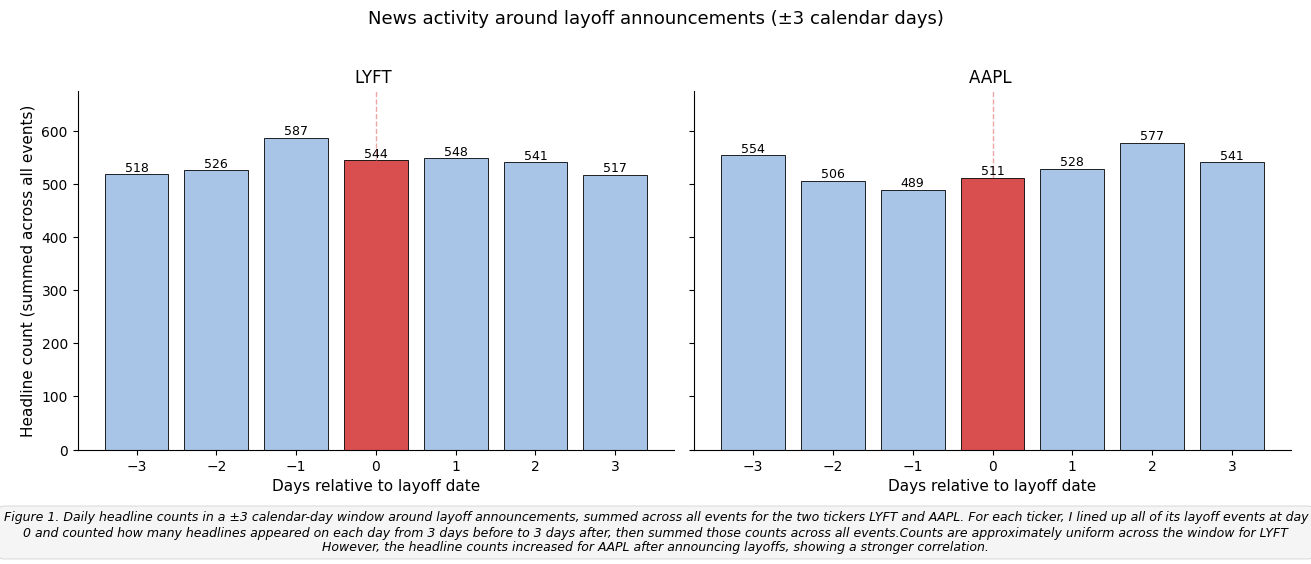

Wrote task1_news_around_layoffs.png


In [94]:
# ===============================================================
# TASK 1: News activity around layoff events

# ===============================================================

company_news["date"] = company_news["datetime"].dt.normalize()

# Identify the top 2 tickers by number of layoff events
top2 = layoffs["ticker"].value_counts().head(2).index.tolist()
print(f"Top 2 tickers by layoff event count: {top2}")

# Restrict to those tickers
events = (
    layoffs.loc[layoffs["ticker"].isin(top2), ["ticker", "date"]]
    .rename(columns={"date": "event_date"})
)

# Build a long frame: one row per (event, offset)
offsets = pd.DataFrame({"offset": range(-3, 3 + 1)})
events_long = events.merge(offsets, how="cross")
events_long["window_date"] = events_long["event_date"] + pd.to_timedelta(
    events_long["offset"], unit="D"
)

# Pre-aggregate headline counts per (ticker, date)
headline_counts = (
    company_news.groupby(["ticker", "date"]).size().reset_index(name="n_headlines")
)

events_long = events_long.merge(
    headline_counts,
    how="left",
    left_on=["ticker", "window_date"],
    right_on=["ticker", "date"],
).fillna({"n_headlines": 0})

# Aggregate: total headlines at each (ticker, relative-day offset)
task1 = (
    events_long.groupby(["ticker", "offset"])["n_headlines"]
    .sum()
    .reset_index()
    .sort_values(["ticker", "offset"])
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)

bar_color = "#a8c5e8"
event_color = "#d94f4f"

for ax, ticker in zip(axes, top2):
    sub = task1[task1["ticker"] == ticker]
    n_events = (events["ticker"] == ticker).sum()

    colors = [
        event_color if o == 0 else bar_color for o in sub["offset"]
    ]
    bars = ax.bar(sub["offset"], sub["n_headlines"],
                  color=colors, edgecolor="black", linewidth=0.6)

    ax.axvline(0, color=event_color, linestyle="--", linewidth=1, alpha=0.5)
    for bar, count in zip(bars, sub["n_headlines"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{int(count):,}", ha="center", va="bottom", fontsize=9)

    ax.set_xticks(range(-3, 3 + 1))
    ax.set_xlabel("Days relative to layoff date", fontsize=11)
    ax.set_title(f"{ticker} ", fontsize=12)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Headline count (summed across all events)", fontsize=11)

# Pad the y-axis so the value labels don't get clipped
ymax = task1["n_headlines"].max() * 1.15
axes[0].set_ylim(0, ymax)

fig.suptitle(
    f"News activity around layoff announcements (±{3} calendar days)",
    fontsize=13, y=1.02,
)
plt.tight_layout()


caption_task1 = (
    "Figure 1. Daily headline counts in a ±3 calendar-day window around "
    "layoff announcements, summed across all events for the two tickers "
    "LYFT and AAPL. For each ticker, I lined up all of its layoff events at day 0 and counted how many headlines appeared on each day from 3 days before to 3 days after, then summed those counts across all events.Counts are "
    "approximately uniform across the window for LYFT "
    "However, the headline counts increased for AAPL after announcing layoffs, showing a stronger correlation."
)
fig.subplots_adjust(bottom=0.22)
fig.text(0.5, 0.03, caption_task1, ha="center", va="bottom",
         fontsize=9, style="italic", wrap=True,
         bbox=dict(boxstyle="round,pad=0.4", facecolor="#f5f5f5",
                   edgecolor="#cccccc", linewidth=0.5))



task1_path = "task1_news_around_layoffs.png"
plt.savefig(task1_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print(f"Wrote {task1_path}")

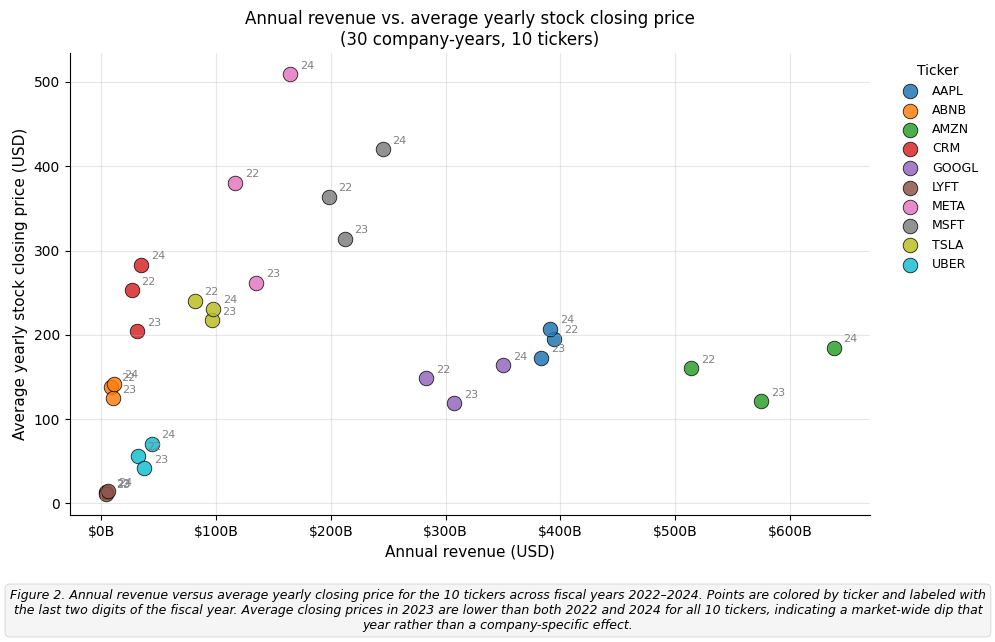

Wrote task2_revenue_vs_stock.png


In [95]:
annual_revenue = pd.read_csv("annual_revenue.csv")
ticker_map = pd.read_csv("cik_ticker_latest.csv")

revenue_with_ticker = annual_revenue.merge(
    ticker_map[["company", "ticker"]],
    on="company",
    how="inner",
)

# Average close per (ticker, calendar year)
stock_prices["fiscal_year"] = stock_prices["date"].dt.year
yearly_avg = (
    stock_prices.dropna(subset=["close"])
    .groupby(["ticker", "fiscal_year"])["close"]
    .mean()
    .reset_index(name="avg_close_price")
)

task2 = revenue_with_ticker.merge(
    yearly_avg, on=["ticker", "fiscal_year"], how="inner"
)

# ---- Plot ----
fig, ax = plt.subplots(figsize=(10, 6.5))

tickers = sorted(task2["ticker"].unique())
cmap = plt.get_cmap("tab10")
colors = {t: cmap(i % 10) for i, t in enumerate(tickers)}

for ticker in tickers:
    sub = task2[task2["ticker"] == ticker]
    ax.scatter(
        sub["revenue_value"],
        sub["avg_close_price"],
        s=110,
        color=colors[ticker],
        edgecolor="black",
        linewidth=0.6,
        alpha=0.85,
        label=ticker,
    )
    # Label each point with its fiscal year, slightly offset
    for _, row in sub.iterrows():
        ax.annotate(
            str(int(row["fiscal_year"]))[-2:],  # last two digits, e.g. "23"
            (row["revenue_value"], row["avg_close_price"]),
            xytext=(7, 4),
            textcoords="offset points",
            fontsize=8,
            color="gray",
        )

# Format the revenue axis in billions
def billions(x, _):
    return f"${x/1e9:.0f}B"

ax.xaxis.set_major_formatter(plt.FuncFormatter(billions))
ax.set_xlabel("Annual revenue (USD)", fontsize=11)
ax.set_ylabel("Average yearly stock closing price (USD)", fontsize=11)
ax.set_title(
    "Annual revenue vs. average yearly stock closing price\n"
    f"({len(task2)} company-years, {len(tickers)} tickers)",
    fontsize=12,
)
ax.legend(title="Ticker", loc="upper left", bbox_to_anchor=(1.02, 1),
          frameon=False, fontsize=9)
ax.grid(True, alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

caption_task2 = (
    "Figure 2. Annual revenue versus average yearly closing price for "
    "the 10 tickers across fiscal years 2022–2024. "
        "Points are colored by ticker and labeled with the last two digits "
    "of the fiscal year. Average closing prices in 2023 are lower than "
    "both 2022 and 2024 for all 10 tickers, indicating a market-wide "
    "dip that year rather than a company-specific effect."
)
fig.subplots_adjust(bottom=0.20)
fig.text(0.5, 0.02, caption_task2, ha="center", va="bottom",
         fontsize=9, style="italic", wrap=True,
         bbox=dict(boxstyle="round,pad=0.4", facecolor="#f5f5f5",
                   edgecolor="#cccccc", linewidth=0.5))


task2_path = "task2_revenue_vs_stock.png"
plt.savefig(task2_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print(f"Wrote {task2_path}")